In [1]:
import YB_Pcb_Car  #Import Yahboom car library
import time
import RPi.GPIO as GPIO
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from picamera.array import PiRGBArray
from picamera import PiCamera
import cv2
import os
import ipywidgets.widgets as widgets
import enum
from imutils import paths
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import csv
from collections import deque

In [2]:
def bgr8_to_jpeg(value, quality=75):
    return bytes(cv2.imencode('.jpg', value)[1])

car = YB_Pcb_Car.YB_Pcb_Car()
Tracking_Left1 = 13   #X1B Left 1 IR sensor
Tracking_Left2 = 15   #X2B Left 2 IR sensor
Tracking_Right1 = 11   #X1A  Right 1 IR sensor
Tracking_Right2 = 7  #X2A  Right 2 IR sensor
previousError = 0
I = 0
MSEarray = []
MAEarray = []
RMSEarray = []

GPIO.setmode(GPIO.BOARD)

GPIO.setwarnings(False)

GPIO.setup(Tracking_Left1,GPIO.IN)
GPIO.setup(Tracking_Left2,GPIO.IN)
GPIO.setup(Tracking_Right1,GPIO.IN)
GPIO.setup(Tracking_Right2,GPIO.IN)

In [3]:
def readBlackLine():
    # Read the input from the four tracking sensors and invert the values
    # GPIO.input() returns the current value of the specified GPIO pin.
    Tracking_Left1Value = (GPIO.input(Tracking_Left1) + 1) % 2
    Tracking_Left2Value = (GPIO.input(Tracking_Left2) + 1) % 2
    Tracking_Right1Value = (GPIO.input(Tracking_Right1) + 1) % 2
    Tracking_Right2Value = (GPIO.input(Tracking_Right2) + 1) % 2
    
    # Calculate a unique binary value for the current state of all sensors
    infraRedSensors = Tracking_Left1Value * 1 + Tracking_Left2Value * 2 + Tracking_Right1Value * 4 + Tracking_Right2Value * 8
    
    try:
        # Calculate the position of the line based on weighted values of sensor states
        position = (
            Tracking_Left1Value * 0
            + Tracking_Left2Value * 2750 
            + Tracking_Right1Value * 3550
            + Tracking_Right2Value * 6300
        ) / (Tracking_Left1Value + Tracking_Left2Value + Tracking_Right1Value + Tracking_Right2Value)
    
    except ZeroDivisionError:
        # If all sensors are off, return -1 to indicate no line detected
        return -1
    
    # Return the calculated position of the line
    return position

In [4]:
#function to control direction of robot based on prediction from CNN
prevLeftSpeed = 0
prevRightSpeed = 0
leftSpeedArray = []
rightSpeedArray = []
predictionArray = []

def control_robot(image):
  prediction = np.argmax(model.predict(image))
  global prevLeftSpeed, prevRightSpeed
  if prediction == 0:
    print("forward")
    car.Control_Car(60,60)
    prevLeftSpeed = 60
    prevRightSpeed = 60
  elif prediction == 1:
    print("soft_left")
    car.Control_Car(50,70)
    prevLeftSpeed = 50
    prevRightSpeed = 70
  elif prediction == 2:
    print("hard_left")
    car.Control_Car(30,90)
    prevLeftSpeed = 30
    prevRightSpeed = 90
  elif prediction == 3:
    print("spin_left")
    car.Control_Car(-50,70)
    prevLeftSpeed = -50
    prevRightSpeed = 70
  elif prediction == 4:
    print("soft_right")
    car.Control_Car(70,50)
    prevLeftSpeed = 70
    prevRightSpeed = 50
  elif prediction == 5:
    print("hard_right")
    car.Control_Car(90,40)
    prevLeftSpeed = 90
    prevRightSpeed = 40
  elif prediction == 6:
    print("spin_right")
    car.Control_Car(70,-50)
    prevLeftSpeed = 70
    prevRightSpeed = -50
  else:
    print("Lost line")
    if prevLeftSpeed > prevRightSpeed: 
        car.Control_Car(60,-40) 
        prevLeftSpeed = 60
        prevRightSpeed = -40
    else: 
        car.Control_Car(-40,60)
        prevLeftSpeed = -40
        prevRightSpeed = -60
        
  simulationTime.append(time.time()-startTime)
  leftSpeedArray.append(prevLeftSpeed)
  rightSpeedArray.append(prevRightSpeed)
  predictionArray.append(prediction)

In [5]:
car.Ctrl_Servo(1, 83) #The servo connected to the S1 interface on the expansion board, rotate to 90°
time.sleep(0.5)
car.Ctrl_Servo(2, 90) #The servo connected to the S2 interface on the expansion board, rotate to 90°
time.sleep(0.5)

car.Ctrl_Servo(2, 170) #The servo connected to the S2 interface on the expansion board, rotate to 0°
time.sleep(0.5)

In [6]:
# Load the trained model
model = load_model("image_model8.h5")

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
If using Keras pass *_constraint arguments to layers.


In [7]:
# Initialize the camera and grab a reference to the raw camera capture
camera = PiCamera()
camera.resolution = (640, 480)  # Ensure resolution matches the buffer size
camera.framerate = 32
rawCapture = PiRGBArray(camera, size=(640, 480))
# allow the camera to warm up
time.sleep(0.1)

In [8]:
# Threshold value
threshold_value = 130  # Adjust this value based on your needs
# Capture frames from the camera
start = 1
images_path = 'images'
startTime = time.time()
errorArray = []
simulationTime = []

try:
    # Capture frames from the camera
    for frame in camera.capture_continuous(rawCapture, format="bgr", use_video_port=True):
        # Start time of the loop
        loop_start_time = time.time()
        
        error = 3150 - readBlackLine()
        if error == 3151:
            if previousError < 0:
                error = -6000
            else:
                error = 6000
        errorArray.append(error)

        clear_output()
        # Grab the raw NumPy array representing the image
        image = frame.array
        
        # Convert the image to grayscale
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Apply binary thresholding
        _, binary_image = cv2.threshold(gray_image, threshold_value, 255, cv2.THRESH_BINARY)
        # Crop the bottom part
        binary_image = binary_image[:230, :]
        
        # Display the binary image
        image_widget = widgets.Image(format='jpg', width=640, height=480)
        display(image_widget)
        _, jpeg = cv2.imencode('.jpg', binary_image)
        image_widget.value = jpeg.tobytes()
    
        # Resize, normalize, and expand dimensions
        binary_image = cv2.resize(binary_image, (36, 36)).astype("float") / 255.0
        binary_image = np.expand_dims(binary_image, axis=-1)  # Add channel dimension (28, 28, 1)
        binary_image = np.expand_dims(binary_image, axis=0)   # Add batch dimension (1, 28, 28, 1)
    
        control_robot(binary_image)
    
        # Clear the stream in preparation for the next frame
        rawCapture.truncate(0)

        # End time of the loop
        loop_end_time = time.time()

        # Calculate the time taken for this loop iteration
        loop_duration = loop_end_time - loop_start_time
        print(f"Time taken for one loop: {loop_duration:.4f} seconds")
        
except KeyboardInterrupt:
    print("Program interrupted by user. Exiting...")

PiCameraRuntimeError: No data recevied from sensor. Check all connections, including the SUNNY chip on the camera board

In [9]:
# Close the camera properly
camera.close()
print("Camera closed")
car.Car_Stop()

PiCameraRuntimeError: No data recevied from sensor. Check all connections, including the SUNNY chip on the camera board

ValueError: x and y must have same first dimension, but have shapes (244,) and (1440,)

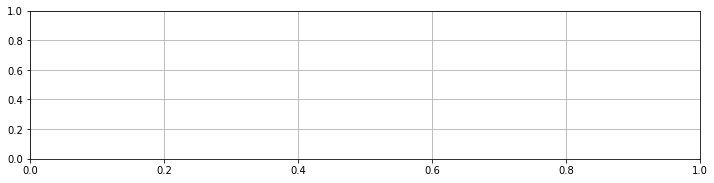

In [41]:
# Plot the error values against simulation time with a red line
plt.figure(figsize=(12, 6))  # Adjust the width and height values as needed
ax = plt.subplot(2,1,1)
ax.grid()
plt.plot(simulationTime, leftSpeedArray, label='Velocidade esquerda', color='purple')
plt.plot(simulationTime, rightSpeedArray, label='Velocidade direita', color='green')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade')
plt.legend()
ax = plt.subplot(2,1,2)
ax.grid()
plt.plot(simulationTime, predictionArray, label='Saída da rede', color='red')
plt.xlabel('Tempo (s)')
plt.ylabel('Label')
plt.legend()
plt.show()

In [42]:
# MSE: Mean Squared Error
mse = np.mean(np.square(errorArray))

# MAE: Mean Absolute Error
mae = np.mean(np.abs(errorArray))

# RMSE: Root Mean Squared Error
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print(simulationTime[-1])

MSE: 22867652.265482694
MAE: 4153.312841530054
RMSE: 4782.013411261275
26.278130292892456


In [43]:
MSEarray.append(mse)
MAEarray.append(mae)
RMSEarray.append(rmse)

In [44]:
print(MSEarray)
print(MAEarray)
print(RMSEarray)

[20428651.041666668, 21950816.11570248, 19632847.510373443, 20320868.055555556, 22867652.265482694]
[3742.2916666666665, 3999.1735537190084, 3658.713692946058, 3730.3961748633883, 4153.312841530054]
[4519.806527017132, 4685.1698064960765, 4430.896919402825, 4507.867351149051, 4782.013411261275]


In [45]:
times = [25.62, 25.83, 25.73, 26.33, 26.28]
print("MSE average =", np.mean(MSEarray))
print("MSE deviation =", np.std(MSEarray))
print("MAE average =", np.mean(MAEarray))
print("MAE deviation =", np.std(MAEarray))
print("RMSE average =", np.mean(RMSEarray))
print("RMSE deviation =", np.std(RMSEarray))
print("Time average =", np.mean(times))
print("Time deviation =", np.std(times))

MSE average = 21040166.99775617
MSE deviation = 1186665.504019059
MAE average = 3856.7775859450353
MAE deviation = 187.8927150972441
RMSE average = 4585.150803065271
RMSE deviation = 128.68220897258055
Time average = 25.958000000000006
Time deviation = 0.2914378149794563
